# Load All the necessary Libraries and Stuffs for Working and creating the model

In [1]:
%%time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_curve,auc
)
#Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

CPU times: total: 3.44 s
Wall time: 3.67 s


In [2]:
%%time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_curve,auc
)
#Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

CPU times: total: 0 ns
Wall time: 51.7 μs


In [3]:
%%time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_curve,auc
)
#Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

CPU times: total: 0 ns
Wall time: 85.4 μs


In [4]:
# Utility functions
from utils import evaluate_model, plot_confusion_matrix, plot_roc_curves, compare_models

In [5]:
sns.set_theme(style = 'whitegrid')
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# Load Data

In [6]:
df = pd.read_csv('data/clean_titanic_data.csv')
print(f'Dataset Shape : {df.shape}')
print(f'Rows : {df.shape[0]}')
print(f'Columns : {df.shape[1]}')
df.head()

Dataset Shape : (891, 26)
Rows : 891
Columns : 26


,Unnamed: 0,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Has_Cabin,...,AgeGroup_Adult,AgeGroup_Senior,AgeGroup_Teen,AgeGroup_Young Adult,AgeGroup_child,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_rare
0,0,0,3,0,22.0,1,0,7.2500,S,0,...,0,0,0,1,0,0,0,1,0,0
1,1,1,1,1,38.0,1,0,71.2833,C,1,...,1,0,0,0,0,0,0,0,1,0
2,2,1,3,1,26.0,0,0,7.9250,S,0,...,0,0,0,1,0,0,1,0,0,0
3,3,1,1,1,35.0,1,0,53.1000,S,1,...,0,0,0,1,0,0,0,0,1,0
4,4,0,3,0,35.0,0,0,8.0500,S,0,...,0,0,0,1,0,0,0,1,0,0


In [7]:
df = pd.get_dummies(df,columns = ['Embarked'],dtype=int)

In [8]:
df

,Unnamed: 0,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Has_Cabin,Family_Size,...,AgeGroup_Young Adult,AgeGroup_child,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_rare,Embarked_C,Embarked_Q,Embarked_S
0,0,0,3,0,22.0,1,0,7.2500,0,2,...,1,0,0,0,1,0,0,0,0,1
1,1,1,1,1,38.0,1,0,71.2833,1,2,...,0,0,0,0,0,1,0,1,0,0
2,2,1,3,1,26.0,0,0,7.9250,0,1,...,1,0,0,1,0,0,0,0,0,1
3,3,1,1,1,35.0,1,0,53.1000,1,2,...,1,0,0,0,0,1,0,0,0,1
4,4,0,3,0,35.0,0,0,8.0500,0,1,...,1,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,886,0,2,0,27.0,0,0,13.0000,0,1,...,1,0,0,0,0,0,1,0,0,1
887,887,1,1,1,19.0,0,0,30.0000,1,1,...,1,0,0,1,0,0,0,0,0,1
888,888,0,3,1,21.5,1,2,23.4500,0,4,...,1,0,0,1,0,0,0,0,0,1
889,889,1,1,0,26.0,0,0,30.0000,1,1,...,1,0,0,0,1,0,0,1,0,0


# Seperate the Features and the Target and keep them in variables

## Features Variable

In [9]:
X = df.drop(columns = {'Survived'})

## Target Variable

In [10]:
Y = df['Survived']

In [11]:
print(f'Shape of Features : {X.shape}')

Shape of Features : (891, 27)


In [12]:
print(f'Shape of Target : {Y.shape}')

Shape of Target : (891,)


In [13]:
print(f'Target DIstribution : {Y.value_counts()}')

Target DIstribution : Survived
0    549
1    342
Name: count, dtype: int64


In [14]:
print(f'Feature Columns : {X.columns.to_list()}')

Feature Columns : ['Unnamed: 0', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Has_Cabin', 'Family_Size', 'IsAlone', 'Farebins_High', 'Farebins_Low', 'Farebins_Very High', 'Farebins_medium', 'AgeGroup_Adult', 'AgeGroup_Senior', 'AgeGroup_Teen', 'AgeGroup_Young Adult', 'AgeGroup_child', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_rare', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


### TRAIN TEST SPLIT (80/20)

### x_train = training data
### x_test = testing data
### y_train = answe key for training data
### y_test = answer key for testing data

In [15]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size = 0.2,random_state = 42,stratify = Y)

In [16]:
print(f'Training Set : {x_train.shape[0]} samples');
print(f'Test Set : {x_test.shape[0]} samples');

Training Set : 712 samples
Test Set : 179 samples


In [17]:
print(f'Training Survival Rate : {y_train.mean():.2%}')
print(f'Test Survival Rate :{ y_test.mean():.2%}')

Training Survival Rate : 38.34%
Test Survival Rate :38.55%


# Feature Scaling

In [18]:
scalar = StandardScaler()

In [19]:
x_train_scaled = scalar.fit_transform(x_train)
x_train_scaled = pd.DataFrame(x_train_scaled,columns = x_train.columns,index = x_train.index)
x_train_scaled = x_train_scaled.drop(columns  = {'Unnamed: 0'})

In [20]:
x_train_scaled.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Has_Cabin,Family_Size,IsAlone,Farebins_High,...,AgeGroup_Young Adult,AgeGroup_child,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_rare,Embarked_C,Embarked_Q,Embarked_S
692,0.829568,-0.742427,-0.322182,-0.465084,-0.466183,0.513812,-0.538382,-0.556339,0.800346,-0.570863,...,0.875642,-0.289333,-0.213357,-0.496926,0.853320,-0.420547,-0.174329,-0.492527,-0.289333,0.611978
481,-0.370945,-0.742427,0.053575,-0.465084,-0.466183,-0.662563,-0.538382,-0.556339,0.800346,-0.570863,...,0.875642,-0.289333,-0.213357,-0.496926,0.853320,-0.420547,-0.174329,-0.492527,-0.289333,0.611978
527,-1.571457,-0.742427,0.805089,-0.465084,-0.466183,3.955399,1.857418,-0.556339,0.800346,-0.570863,...,-1.142019,-0.289333,-0.213357,-0.496926,0.853320,-0.420547,-0.174329,-0.492527,-0.289333,0.611978
855,0.829568,1.346933,-0.848242,-0.465084,0.727782,-0.467874,-0.538382,0.073412,-1.249460,-0.570863,...,-1.142019,-0.289333,-0.213357,-0.496926,-1.171893,2.377857,-0.174329,-0.492527,-0.289333,0.611978
801,-0.370945,1.346933,0.128726,0.478335,0.727782,-0.115977,-0.538382,0.703162,-1.249460,1.751734,...,0.875642,-0.289333,-0.213357,-0.496926,-1.171893,2.377857,-0.174329,-0.492527,-0.289333,0.611978


In [21]:
x_test_scaled = scalar.transform(x_test)
x_test_scaled = pd.DataFrame(x_test_scaled,columns = x_test.columns,index = x_test.index)
x_test_scaled = x_test_scaled.drop(columns = {'Unnamed: 0'})
x_test_scaled.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Has_Cabin,Family_Size,IsAlone,Farebins_High,...,AgeGroup_Young Adult,AgeGroup_child,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_rare,Embarked_C,Embarked_Q,Embarked_S
565,0.829568,-0.742427,-0.397333,1.421753,-0.466183,-0.159704,-0.538382,0.703162,-1.249460,1.751734,...,0.875642,-0.289333,-0.213357,-0.496926,0.853320,-0.420547,-0.174329,-0.492527,-0.289333,0.611978
160,0.829568,-0.742427,1.105694,-0.465084,0.727782,-0.327324,-0.538382,0.073412,-1.249460,1.751734,...,-1.142019,-0.289333,-0.213357,-0.496926,0.853320,-0.420547,-0.174329,-0.492527,-0.289333,0.611978
553,0.829568,-0.742427,-0.547636,-0.465084,-0.466183,-0.512122,-0.538382,-0.556339,0.800346,-0.570863,...,0.875642,-0.289333,-0.213357,-0.496926,0.853320,-0.420547,-0.174329,2.030345,-0.289333,-1.634045
860,0.829568,-0.742427,0.880240,1.421753,-0.466183,-0.368795,-0.538382,0.703162,-1.249460,-0.570863,...,-1.142019,-0.289333,-0.213357,-0.496926,0.853320,-0.420547,-0.174329,-0.492527,-0.289333,0.611978
241,0.829568,1.346933,-0.585212,0.478335,-0.466183,-0.339817,-0.538382,0.073412,-1.249460,1.751734,...,0.875642,-0.289333,-0.213357,2.012373,-1.171893,-0.420547,-0.174329,-0.492527,3.456220,-1.634045


# Train Models

In [22]:
result = []
trained_models = {}

## Logistic Regression

In [23]:
# Creating the model object and setting iterations to 1000 times so that it gets enough chances to imporove errors in weighting
lr = LogisticRegression(random_state = 42,max_iter = 1000)

In [24]:
lr.fit(x_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [25]:
y_predic = lr.predict(x_test_scaled)

In [26]:
metrics_lr = evaluate_model(y_test,y_predic,'Logistic Regression')

Logistic Regression Results : 
MODEL     : Logistic Regression
ACCURACY  : 0.8435754189944135
PRECISION : 0.7971014492753623
RECALL    : 0.7971014492753623
F1 SCORE  : 0.7971014492753623


In [27]:
result.append(metrics_lr)

In [28]:
trained_models["Logistic Regression"] = lr

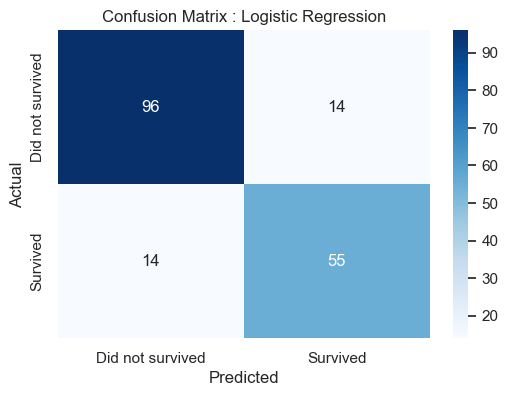

In [29]:
plot_confusion_matrix(y_test,y_predic,'Logistic Regression')

# *Decision Tree* 

In [30]:
dt = DecisionTreeClassifier(random_state  = 42,max_depth = 5)

### Train the model

In [31]:
dt.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [32]:
y_pred = dt.predict(x_test)

In [33]:
trained_models['Decision Tree'] = dt

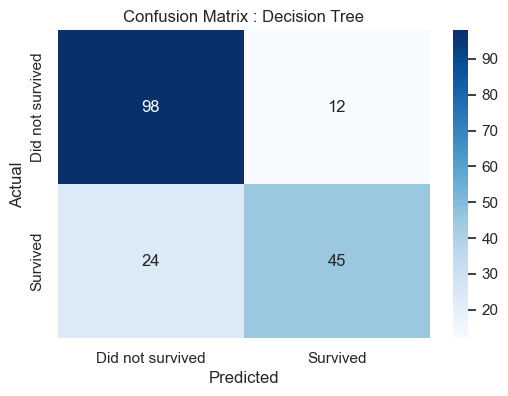

In [34]:
plot_confusion_matrix(y_test,y_pred,'Decision Tree')

In [35]:
metrics_dt = evaluate_model(y_test,y_pred,"Decision Tree")

Decision Tree Results : 
MODEL     : Decision Tree
ACCURACY  : 0.7988826815642458
PRECISION : 0.7894736842105263
RECALL    : 0.6521739130434783
F1 SCORE  : 0.7142857142857143


In [36]:
result.append(metrics_dt)

### Feature Importance

In [37]:
feat_imp = pd.Series(dt.feature_importances_,index = x_train.columns)

In [38]:
feat_imp

Unnamed: 0              0.003362
Pclass                  0.129370
Sex                     0.000000
Age                     0.048653
SibSp                   0.000000
Parch                   0.000000
Fare                    0.074986
Has_Cabin               0.077666
Family_Size             0.072941
IsAlone                 0.000000
Farebins_High           0.000000
Farebins_Low            0.000000
Farebins_Very High      0.000000
Farebins_medium         0.020621
AgeGroup_Adult          0.006825
AgeGroup_Senior         0.000000
AgeGroup_Teen           0.000000
AgeGroup_Young Adult    0.000000
AgeGroup_child          0.000000
Title_Master            0.000000
Title_Miss              0.000000
Title_Mr                0.524030
Title_Mrs               0.000000
Title_rare              0.041545
Embarked_C              0.000000
Embarked_Q              0.000000
Embarked_S              0.000000
dtype: float64

In [39]:
feat_imp = feat_imp.drop(index = 'Unnamed: 0')

In [40]:
feat_imp  = feat_imp.sort_values(ascending  = True)
feat_imp

Embarked_S              0.000000
AgeGroup_Teen           0.000000
AgeGroup_Senior         0.000000
Embarked_Q              0.000000
Farebins_Very High      0.000000
Farebins_Low            0.000000
Farebins_High           0.000000
AgeGroup_Young Adult    0.000000
IsAlone                 0.000000
Title_Miss              0.000000
Title_Mrs               0.000000
Parch                   0.000000
SibSp                   0.000000
Embarked_C              0.000000
Sex                     0.000000
Title_Master            0.000000
AgeGroup_child          0.000000
AgeGroup_Adult          0.006825
Farebins_medium         0.020621
Title_rare              0.041545
Age                     0.048653
Family_Size             0.072941
Fare                    0.074986
Has_Cabin               0.077666
Pclass                  0.129370
Title_Mr                0.524030
dtype: float64

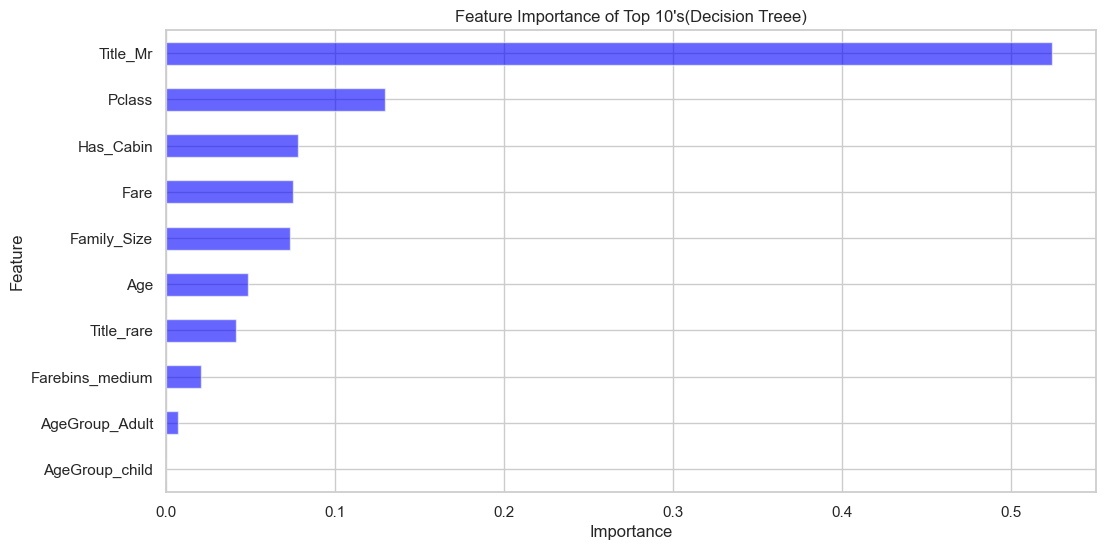

In [41]:
fig,ax = plt.subplots(figsize = (12,6,));
feat_imp.tail(10).plot(kind = 'barh',ax = ax,color = 'blue',alpha = 0.6);
ax.set_title("Feature Importance of Top 10's(Decision Treee)");
ax.set_xlabel('Importance');
ax.set_ylabel('Feature');

## Randon Forest

In [42]:
rf = RandomForestClassifier(n_estimators = 100,random_state = 42,max_depth = 7)

In [43]:
rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Test the model against the testing data

In [44]:
y_pred_rf = rf.predict(x_test)

In [45]:
metrics_rf = evaluate_model(y_test,y_pred_rf,"Random Forest")

Random Forest Results : 
MODEL     : Random Forest
ACCURACY  : 0.8324022346368715
PRECISION : 0.8
RECALL    : 0.7536231884057971
F1 SCORE  : 0.7761194029850746


In [46]:
result.append(metrics_rf)

In [47]:
trained_models['Random Forest'] = rf

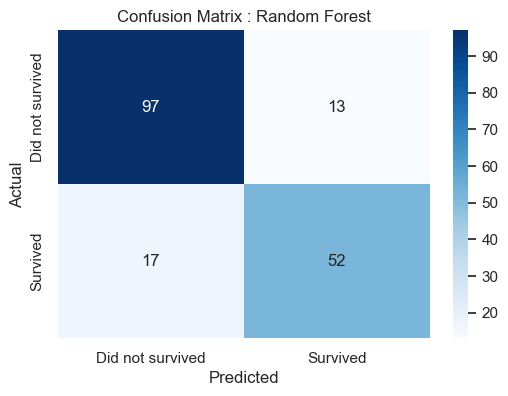

In [48]:
plot_confusion_matrix(y_test,y_pred_rf,"Random Forest")

### Feature Importance for Random Forest

In [49]:
feat_imp_rf = pd.Series(rf.feature_importances_,index = x_train.columns)

In [50]:
feat_imp_rf = feat_imp_rf.sort_values(ascending = True)

In [51]:
feat_imp_rf = feat_imp_rf.drop(index = 'Unnamed: 0')

In [52]:
feat_imp_rf

AgeGroup_Senior         0.001126
AgeGroup_Teen           0.004495
Title_Master            0.005780
Embarked_Q              0.006514
Title_rare              0.007077
Farebins_medium         0.007678
AgeGroup_Young Adult    0.008110
Farebins_High           0.008470
AgeGroup_child          0.008643
Embarked_C              0.008656
AgeGroup_Adult          0.009714
IsAlone                 0.010169
Farebins_Low            0.011068
Embarked_S              0.012471
Parch                   0.013268
Farebins_Very High      0.014049
SibSp                   0.033315
Title_Miss              0.040783
Family_Size             0.043728
Title_Mrs               0.045102
Has_Cabin               0.046920
Pclass                  0.067382
Age                     0.068843
Fare                    0.109982
Sex                     0.161936
Title_Mr                0.181902
dtype: float64

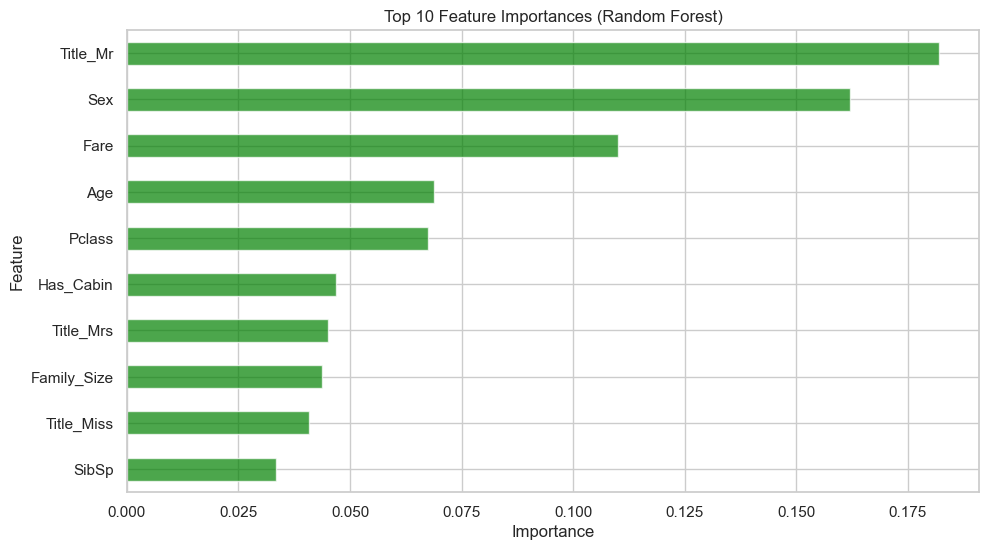

In [53]:
fig,ax = plt.subplots(figsize = (11,6));
feat_imp_rf.tail(10).plot(kind = 'barh',color = 'green',alpha = 0.7,ax = ax);
ax.set_xlabel('Importance');
ax.set_ylabel('Feature');
ax.set_title('Top 10 Feature Importances (Random Forest)');

# K-Nearest Neighbors (KNN)

In [54]:
knn = KNeighborsClassifier(n_neighbors = 5)

## Train it

In [55]:
x_train= x_train.drop(columns = {'Unnamed: 0'})
y_train = y_train.drop(columns = {'Unnamed: 0'})

In [56]:
knn.fit(x_train_scaled,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [57]:
y_pred_knn = knn.predict(x_test_scaled)

In [58]:
metrics_knn = evaluate_model(y_test,y_pred_knn,"K-Nearest Neighbors")

K-Nearest Neighbors Results : 
MODEL     : K-Nearest Neighbors
ACCURACY  : 0.7821229050279329
PRECISION : 0.75
RECALL    : 0.6521739130434783
F1 SCORE  : 0.6976744186046512


In [59]:
result.append(metrics_knn)

In [60]:
trained_models['K-Nearest Neighbors'] = knn

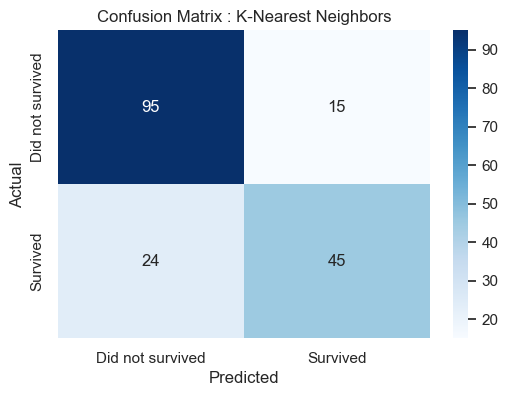

In [61]:
plot_confusion_matrix(y_test,y_pred_knn,'K-Nearest Neighbors')

### Finding Optimal K value by Cross Validation Method

In [62]:
k_ranges = range(1,22)
k_scores = []
for i in k_ranges:
    kn = KNeighborsClassifier(n_neighbors = i)
    scores = cross_val_score(kn,x_train_scaled,y_train,cv = 5,scoring = 'accuracy')
    k_scores.append(scores.mean())

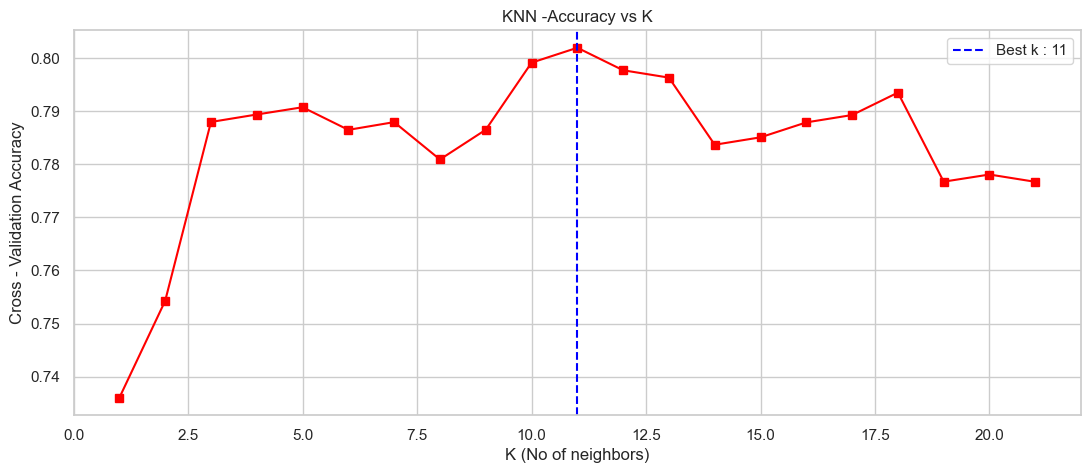

In [63]:
fig,ax = plt.subplots(figsize = (13,5))
ax.plot(k_ranges,k_scores,marker = 's',color = 'red')
best_k = list(k_ranges)[np.argmax(k_scores)]
ax.axvline(x = best_k,color = 'blue',linestyle = '--',label = f"Best k : {best_k}")
ax.set_xlabel('K (No of neighbors)');
ax.set_ylabel('Cross - Validation Accuracy');
ax.set_title('KNN -Accuracy vs K');
ax.legend();

# Support Vector Machine(SVM)

In [64]:
svm = SVC(kernel = 'rbf',probability = True,random_state = 42)

In [65]:
svm.fit(x_train_scaled,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [66]:
y_pred_svm = svm.predict(x_test_scaled)

In [67]:
metrics_svm = evaluate_model(y_test,y_pred_svm,'SVM')

SVM Results : 
MODEL     : SVM
ACCURACY  : 0.8268156424581006
PRECISION : 0.8166666666666667
RECALL    : 0.7101449275362319
F1 SCORE  : 0.7596899224806202


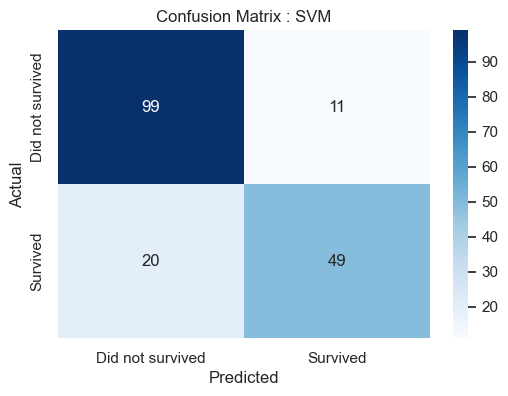

In [68]:
plot_confusion_matrix(y_test,y_pred_svm,'SVM')

# Gradient Boosting

In [69]:
gb = GradientBoostingClassifier(n_estimators = 100,learning_rate = 0.1,max_depth = 3,random_state = 42)

In [70]:
gb.fit(x_train,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [71]:
x_test = x_test.drop(columns = {'Unnamed: 0'})

In [72]:
y_pred_gb = gb.predict(x_test)

In [73]:
metrics_gb = evaluate_model(y_test,y_pred_gb,'Gradient Boosting')

Gradient Boosting Results : 
MODEL     : Gradient Boosting
ACCURACY  : 0.7932960893854749
PRECISION : 0.7758620689655172
RECALL    : 0.6521739130434783
F1 SCORE  : 0.7086614173228346


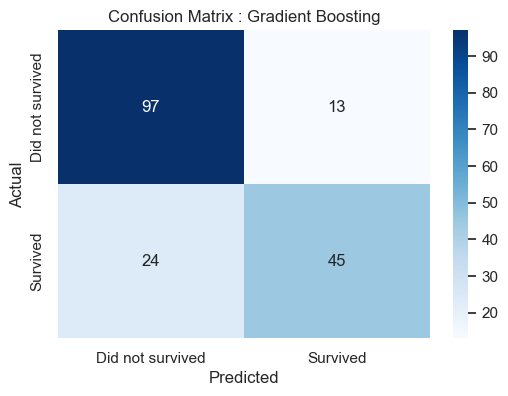

In [74]:
plot_confusion_matrix(y_test,y_pred_gb,'Gradient Boosting')

# Gaussian Naive Bayes

In [75]:
nb = GaussianNB()

In [76]:
nb.fit(x_train_scaled,y_train)

,priors,None
,var_smoothing,1e-09


In [77]:
y_pred_nb = nb.predict(x_test_scaled)

In [78]:
metrics_nb = evaluate_model(y_test,y_pred_nb,'Naive Bayes')

Naive Bayes Results : 
MODEL     : Naive Bayes
ACCURACY  : 0.770949720670391
PRECISION : 0.6707317073170732
RECALL    : 0.7971014492753623
F1 SCORE  : 0.7284768211920529


In [79]:
result.append(metrics_nb)

In [80]:
trained_models['Naive Bayes'] = nb

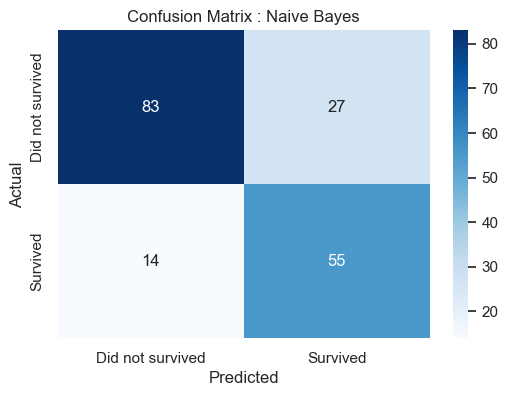

In [81]:
plot_confusion_matrix(y_test,y_pred_nb,'Naive Bayes')